In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Middle_East_Economic_Data_1990_2024_with_Oil.csv")
df

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
0,Bahrain,BHR,1990,101.627082,1.907789,4.809511e+09,4.437997,9342.538914,83.201723,0.929335,72.587,NaN,23.0
1,Bahrain,BHR,1991,74.757141,11.800826,5.248911e+09,11.229998,10434.132396,84.110656,0.764420,72.668,1.047,20.0
2,Bahrain,BHR,1992,74.210844,16.078853,5.402232e+09,6.689998,10460.158322,85.081054,-0.172414,72.785,0.968,18.0
3,Bahrain,BHR,1993,73.764609,-4.650769,5.913001e+09,12.870007,11151.871496,70.998436,2.538860,72.939,0.882,19.0
4,Bahrain,BHR,1994,71.406483,3.289479,6.330628e+09,-0.250001,11629.359522,65.066988,0.816911,73.134,1.007,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,Yemen,YEM,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.435,17.963,45.0
451,Yemen,YEM,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.019,18.312,70.0
452,Yemen,YEM,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.952,17.224,75.0
453,Yemen,YEM,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.295,16.944,80.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               455 non-null    object 
 1   Country_Code                          455 non-null    object 
 2   Year                                  455 non-null    int64  
 3   Exports_pct_GDP                       429 non-null    float64
 4   FDI_net_inflows_pct_GDP               446 non-null    float64
 5   GDP_current_USD                       448 non-null    float64
 6   GDP_growth_annual_pct                 447 non-null    float64
 7   GDP_per_capita_current_USD            448 non-null    float64
 8   Imports_pct_GDP                       429 non-null    float64
 9   Inflation_consumer_prices_annual_pct  395 non-null    float64
 10  Life_expectancy_years                 442 non-null    float64
 11  Unemployment_total_

Missing Values Analysis:
                              Column  Missing_Count  Missing_Percentage
Inflation_consumer_prices_annual_pct             60           13.186813
                     Exports_pct_GDP             26            5.714286
                     Imports_pct_GDP             26            5.714286
              Unemployment_total_pct             14            3.076923
               Life_expectancy_years             13            2.857143
             FDI_net_inflows_pct_GDP              9            1.978022
               GDP_growth_annual_pct              8            1.758242
                     GDP_current_USD              7            1.538462
          GDP_per_capita_current_USD              7            1.538462
                             Country              0            0.000000
                        Country_Code              0            0.000000
                                Year              0            0.000000
      Brent_Oil_Price_USD_per_barrel   

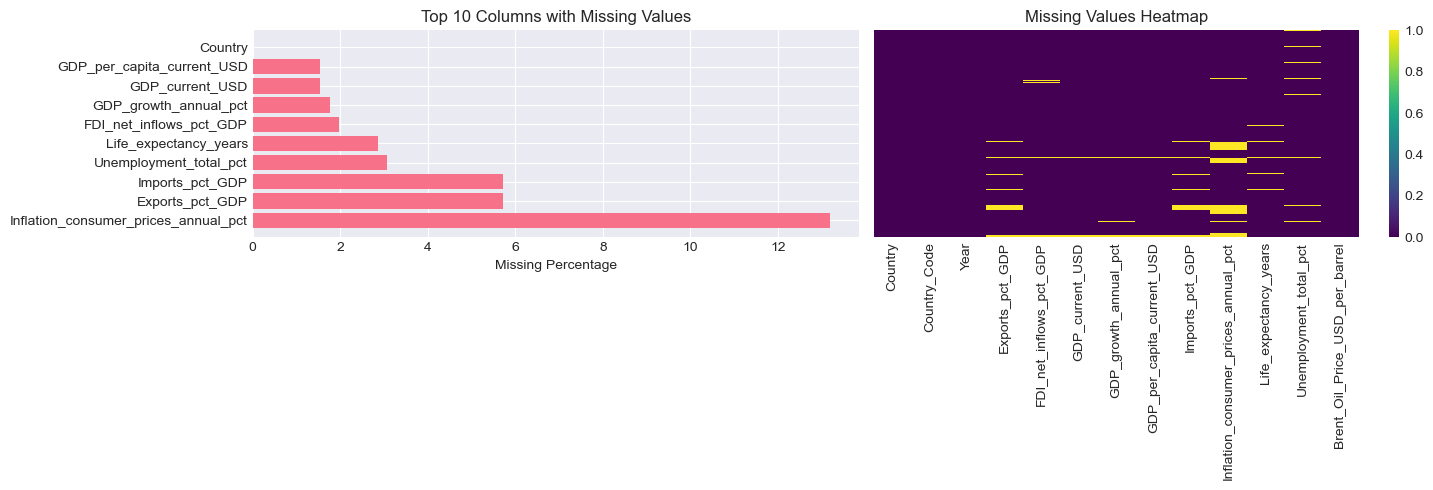


Missing Values by Country:
Country                               Bahrain  Egypt  Iran  Iraq  Israel  \
Country                                     0      0     0     0       0   
Country_Code                                0      0     0     0       0   
Year                                        0      0     0     0       0   
Exports_pct_GDP                             0      0     0     0       0   
FDI_net_inflows_pct_GDP                     0      0     0     2       0   
GDP_current_USD                             0      0     0     0       0   
GDP_growth_annual_pct                       0      0     0     0       0   
GDP_per_capita_current_USD                  0      0     0     0       0   
Imports_pct_GDP                             0      0     0     0       0   
Inflation_consumer_prices_annual_pct        0      0     0     1       0   
Life_expectancy_years                       1      1     1     1       1   
Unemployment_total_pct                      1      1     1  

In [6]:
# Comprehensive missing values analysis
def analyze_missing_values(df):
    missing_df = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Percentage': (df.isnull().sum() / len(df) * 100).values
    }).sort_values('Missing_Percentage', ascending=False)
    
    print("Missing Values Analysis:")
    print(missing_df.to_string(index=False))
    
    # Visualize missing values
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Bar plot
    axes[0].barh(missing_df['Column'][:10], missing_df['Missing_Percentage'][:10])
    axes[0].set_xlabel('Missing Percentage')
    axes[0].set_title('Top 10 Columns with Missing Values')
    
    # Heatmap of missing values
    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, ax=axes[1], cmap='viridis')
    axes[1].set_title('Missing Values Heatmap')
    
    plt.tight_layout()
    plt.show()
    
    return missing_df

missing_analysis = analyze_missing_values(df)

# Check missing patterns by country
missing_by_country = df.groupby('Country').apply(lambda x: x.isnull().sum()).T
print("\nMissing Values by Country:")
print(missing_by_country)

DESCRIPTIVE STATISTICS
          Year  Exports_pct_GDP  FDI_net_inflows_pct_GDP  GDP_current_USD  \
count   455.00           429.00                   446.00     4.480000e+02   
mean   2007.00            43.28                     2.42     1.493333e+11   
std      10.11            22.15                     3.76     1.935098e+11   
min    1990.00             0.01                    -4.65     4.077963e+08   
25%    1998.00            26.54                     0.23     2.303371e+10   
50%    2007.00            39.66                     1.21     7.796705e+10   
75%    2016.00            56.82                     3.75     1.869296e+11   
max    2024.00           106.85                    29.52     1.239805e+12   

       GDP_growth_annual_pct  GDP_per_capita_current_USD  Imports_pct_GDP  \
count                 447.00                      448.00           429.00   
mean                    4.44                    17314.89            40.99   
std                     9.19                    1913

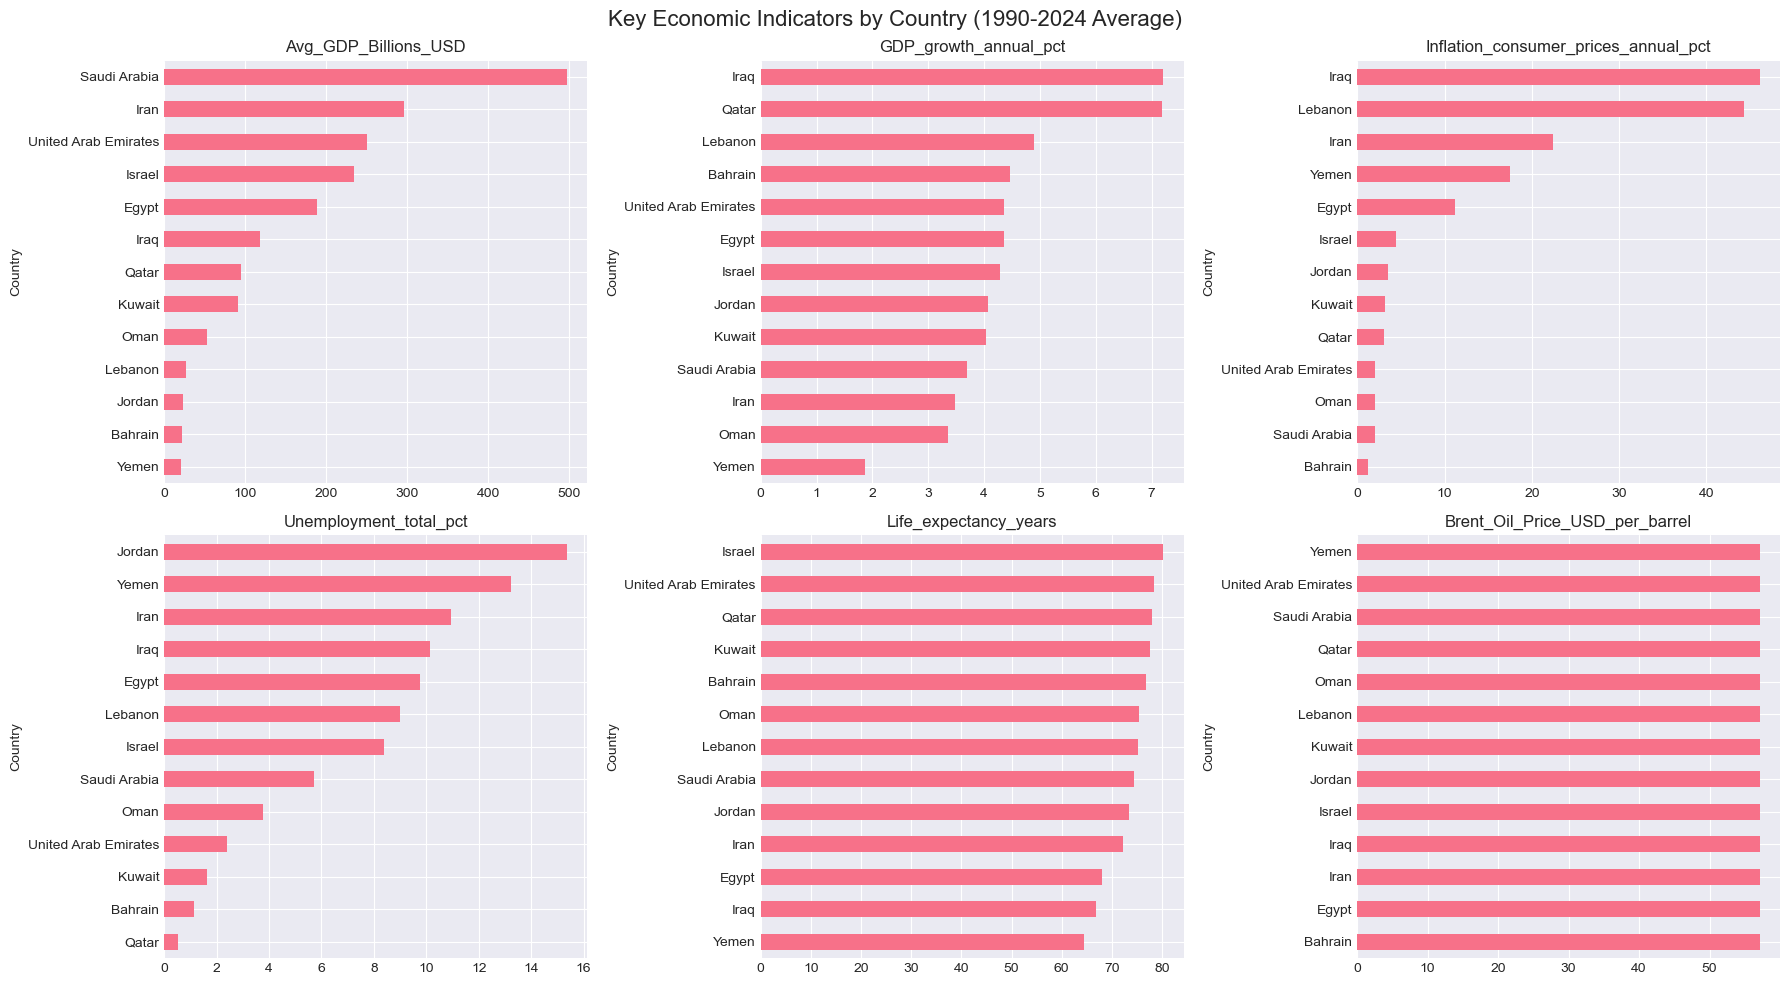

In [7]:
# Comprehensive descriptive statistics
def descriptive_analysis(df):
    # Basic statistics
    print("DESCRIPTIVE STATISTICS")
    print("="*50)
    print(df.describe().round(2))
    
    # Statistics by country
    print("\n" + "="*50)
    print("KEY METRICS BY COUNTRY (Averages 1990-2024)")
    print("="*50)
    
    country_stats = df.groupby('Country').agg({
        'GDP_current_USD': 'mean',
        'GDP_growth_annual_pct': 'mean',
        'Inflation_consumer_prices_annual_pct': 'mean',
        'Unemployment_total_pct': 'mean',
        'Life_expectancy_years': 'mean',
        'Brent_Oil_Price_USD_per_barrel': 'mean'
    }).round(2)
    
    # Format GDP in billions
    country_stats['GDP_current_USD'] = country_stats['GDP_current_USD'] / 1e9
    country_stats.rename(columns={'GDP_current_USD': 'Avg_GDP_Billions_USD'}, inplace=True)
    
    print(country_stats)
    
    return country_stats

country_summary = descriptive_analysis(df)

# Visualize key metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Economic Indicators by Country (1990-2024 Average)', fontsize=16)

metrics = ['Avg_GDP_Billions_USD', 'GDP_growth_annual_pct', 
           'Inflation_consumer_prices_annual_pct', 'Unemployment_total_pct',
           'Life_expectancy_years', 'Brent_Oil_Price_USD_per_barrel']

for idx, metric in enumerate(metrics):
    row, col = idx // 3, idx % 3
    country_summary[metric].sort_values().plot(kind='barh', ax=axes[row, col])
    axes[row, col].set_title(metric)
    axes[row, col].set_xlabel('')

plt.tight_layout()
plt.show()

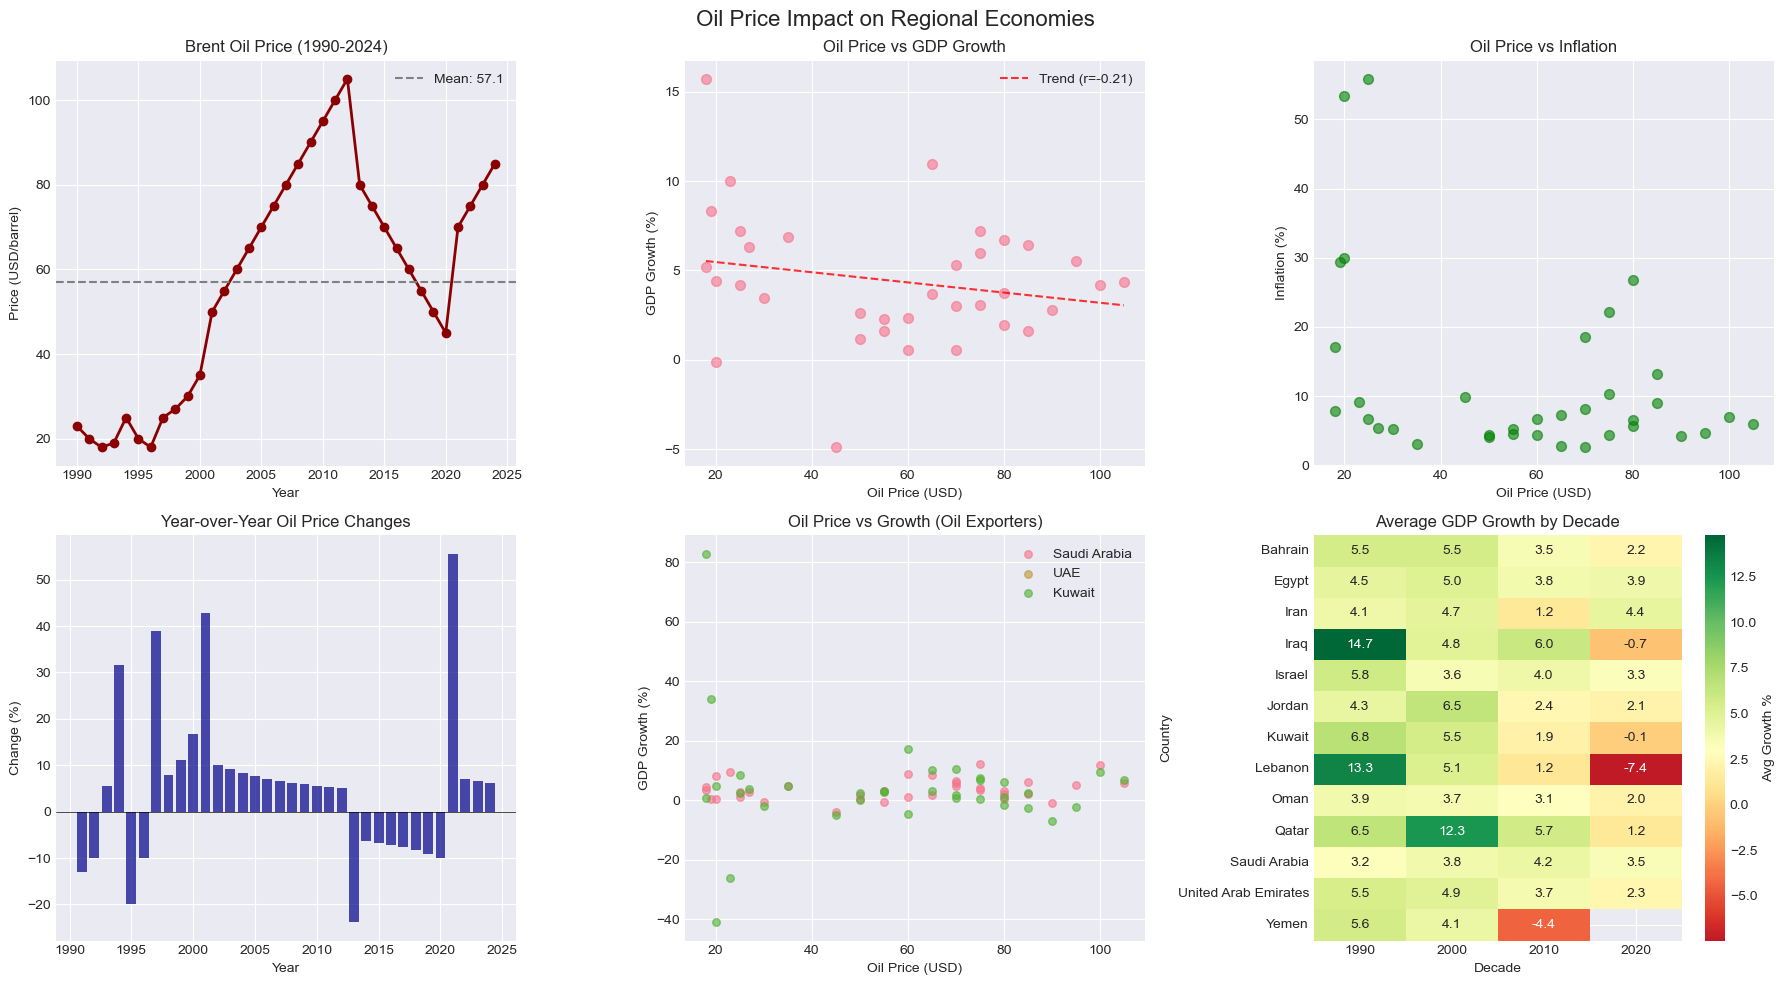

In [8]:
# 4.1 GDP Trends Over Time
def plot_gdp_trends(df):
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Total GDP Over Time', 'GDP Growth Rate', 
                       'GDP per Capita', 'GDP Composition by Country (2024)'),
        specs=[[{'secondary_y': True}, {'secondary_y': False}],
               [{'secondary_y': False}, {'secondary_y': False}]]
    )
    
    # Total GDP with oil price overlay
    for country in df['Country'].unique()[:5]:  # Top 5 countries
        country_data = df[df['Country'] == country]
        fig.add_trace(
            go.Scatter(x=country_data['Year'], y=country_data['GDP_current_USD']/1e9,
                      name=country, mode='lines', line=dict(width=2)),
            row=1, col=1, secondary_y=False
        )
    
    fig.add_trace(
        go.Scatter(x=df['Year'].unique(), y=df.groupby('Year')['Brent_Oil_Price_USD_per_barrel'].mean(),
                  name='Oil Price (Avg)', mode='lines', line=dict(color='black', width=3, dash='dash')),
        row=1, col=1, secondary_y=True
    )
    
    # GDP Growth
    for country in ['Saudi Arabia', 'UAE', 'Qatar', 'Egypt']:
        country_data = df[df['Country'] == country]
        fig.add_trace(
            go.Scatter(x=country_data['Year'], y=country_data['GDP_growth_annual_pct'],
                      name=f'{country} Growth', mode='lines'),
            row=1, col=2
        )
    
    # GDP per Capita (2024)
    gdp_per_capita_2024 = df[df['Year'] == 2024].sort_values('GDP_per_capita_current_USD', ascending=True)
    fig.add_trace(
        go.Bar(x=gdp_per_capita_2024['GDP_per_capita_current_USD'], 
               y=gdp_per_capita_2024['Country'],
               orientation='h', marker_color='lightcoral'),
        row=2, col=1
    )
    
    # Latest GDP composition
    gdp_2024 = df[df['Year'] == 2024].sort_values('GDP_current_USD', ascending=True)
    fig.add_trace(
        go.Bar(x=gdp_2024['GDP_current_USD']/1e9, y=gdp_2024['Country'],
               orientation='h', marker_color='lightgreen'),
        row=2, col=2
    )
    
    fig.update_layout(height=1000, showlegend=True, title_text="GDP Analysis Dashboard")
    fig.update_xaxes(title_text="Year", row=1, col=1)
    fig.update_xaxes(title_text="Year", row=1, col=2)
    fig.update_xaxes(title_text="GDP per Capita (USD)", row=2, col=1)
    fig.update_xaxes(title_text="GDP (Billions USD)", row=2, col=2)
    
    fig.show()

plot_gdp_trends(df)

# 4.2 Oil Price Impact Analysis
def oil_price_impact_analysis(df):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Oil Price Impact on Regional Economies', fontsize=16)
    
    # Calculate year-over-year changes
    df_yearly = df.groupby('Year').agg({
        'GDP_current_USD': 'sum',
        'GDP_growth_annual_pct': 'mean',
        'Inflation_consumer_prices_annual_pct': 'mean',
        'Brent_Oil_Price_USD_per_barrel': 'mean'
    }).reset_index()
    
    df_yearly['GDP_YoY'] = df_yearly['GDP_current_USD'].pct_change() * 100
    df_yearly['Oil_YoY'] = df_yearly['Brent_Oil_Price_USD_per_barrel'].pct_change() * 100
    
    # Plot 1: Oil Price Timeline
    axes[0,0].plot(df_yearly['Year'], df_yearly['Brent_Oil_Price_USD_per_barrel'], 
                   marker='o', linewidth=2, color='darkred')
    axes[0,0].set_title('Brent Oil Price (1990-2024)')
    axes[0,0].set_xlabel('Year')
    axes[0,0].set_ylabel('Price (USD/barrel)')
    axes[0,0].axhline(y=df_yearly['Brent_Oil_Price_USD_per_barrel'].mean(), 
                      color='gray', linestyle='--', label=f"Mean: {df_yearly['Brent_Oil_Price_USD_per_barrel'].mean():.1f}")
    axes[0,0].legend()
    
    # Plot 2: Oil Price vs GDP Growth
    axes[0,1].scatter(df_yearly['Brent_Oil_Price_USD_per_barrel'], 
                      df_yearly['GDP_growth_annual_pct'], alpha=0.6, s=50)
    z = np.polyfit(df_yearly['Brent_Oil_Price_USD_per_barrel'], df_yearly['GDP_growth_annual_pct'], 1)
    p = np.poly1d(z)
    axes[0,1].plot(sorted(df_yearly['Brent_Oil_Price_USD_per_barrel']), 
                   p(sorted(df_yearly['Brent_Oil_Price_USD_per_barrel'])), 
                   "r--", alpha=0.8, label=f"Trend (r={np.corrcoef(df_yearly['Brent_Oil_Price_USD_per_barrel'], df_yearly['GDP_growth_annual_pct'])[0,1]:.2f})")
    axes[0,1].set_title('Oil Price vs GDP Growth')
    axes[0,1].set_xlabel('Oil Price (USD)')
    axes[0,1].set_ylabel('GDP Growth (%)')
    axes[0,1].legend()
    
    # Plot 3: Oil Price vs Inflation
    axes[0,2].scatter(df_yearly['Brent_Oil_Price_USD_per_barrel'], 
                      df_yearly['Inflation_consumer_prices_annual_pct'], alpha=0.6, s=50, color='green')
    axes[0,2].set_title('Oil Price vs Inflation')
    axes[0,2].set_xlabel('Oil Price (USD)')
    axes[0,2].set_ylabel('Inflation (%)')
    
    # Plot 4: Oil Price Shocks Analysis
    axes[1,0].bar(df_yearly['Year'], df_yearly['Oil_YoY'], color='darkblue', alpha=0.7)
    axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1,0].set_title('Year-over-Year Oil Price Changes')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel('Change (%)')
    
    # Plot 5: GDP vs Oil Price (by country type)
    oil_dependent = ['Saudi Arabia', 'UAE', 'Kuwait', 'Qatar', 'Iraq', 'Iran']
    diversified = ['Israel', 'Egypt', 'Jordan', 'Lebanon']
    
    for country in oil_dependent[:3]:
        country_data = df[df['Country'] == country]
        axes[1,1].scatter(country_data['Brent_Oil_Price_USD_per_barrel'], 
                         country_data['GDP_growth_annual_pct'], 
                         alpha=0.6, label=country, s=30)
    
    axes[1,1].set_title('Oil Price vs Growth (Oil Exporters)')
    axes[1,1].set_xlabel('Oil Price (USD)')
    axes[1,1].set_ylabel('GDP Growth (%)')
    axes[1,1].legend()
    
    # Plot 6: Regional Average Growth by Decade
    df['Decade'] = (df['Year'] // 10) * 10
    decade_growth = df.groupby(['Decade', 'Country'])['GDP_growth_annual_pct'].mean().reset_index()
    pivot_growth = decade_growth.pivot(index='Country', columns='Decade', values='GDP_growth_annual_pct')
    
    sns.heatmap(pivot_growth, annot=True, fmt='.1f', cmap='RdYlGn', 
                center=3, ax=axes[1,2], cbar_kws={'label': 'Avg Growth %'})
    axes[1,2].set_title('Average GDP Growth by Decade')
    
    plt.tight_layout()
    plt.show()

oil_price_impact_analysis(df)

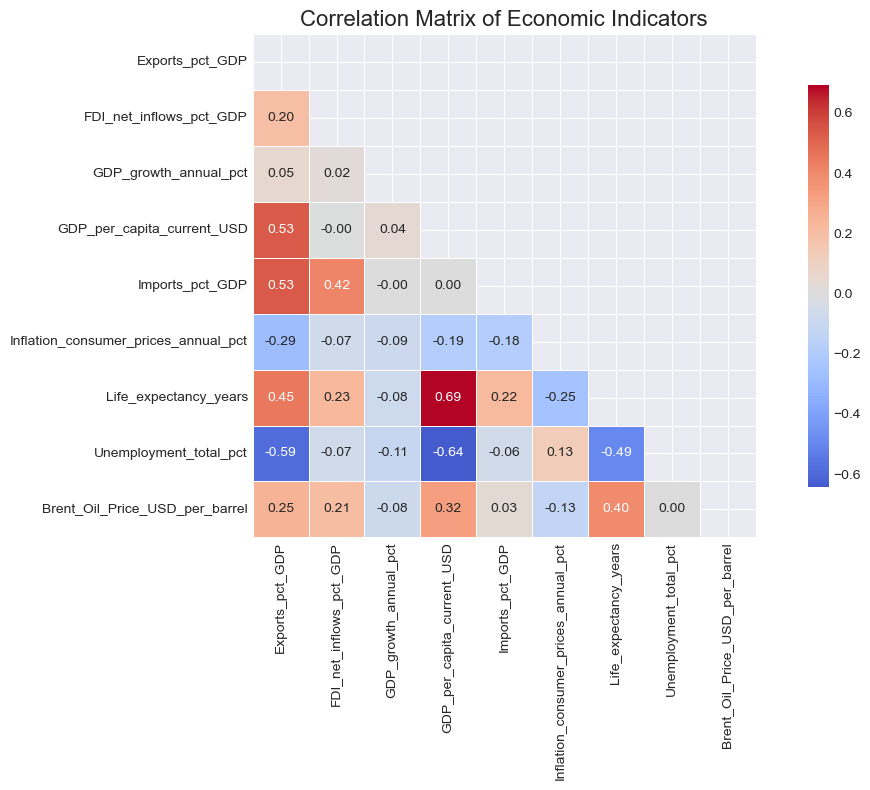


Correlations with Oil Price:
Brent_Oil_Price_USD_per_barrel          1.000000
Life_expectancy_years                   0.395836
GDP_per_capita_current_USD              0.323845
Exports_pct_GDP                         0.253891
FDI_net_inflows_pct_GDP                 0.207825
Imports_pct_GDP                         0.033218
Unemployment_total_pct                  0.003299
GDP_growth_annual_pct                  -0.080540
Inflation_consumer_prices_annual_pct   -0.126616
Name: Brent_Oil_Price_USD_per_barrel, dtype: float64


In [9]:
# Correlation analysis
def correlation_analysis(df):
    # Select numerical columns
    numeric_cols = ['Exports_pct_GDP', 'FDI_net_inflows_pct_GDP', 'GDP_growth_annual_pct',
                   'GDP_per_capita_current_USD', 'Imports_pct_GDP', 
                   'Inflation_consumer_prices_annual_pct', 'Life_expectancy_years',
                   'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel']
    
    # Create correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, 
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Economic Indicators', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Key correlations with Oil Price
    oil_correlations = corr_matrix['Brent_Oil_Price_USD_per_barrel'].sort_values(ascending=False)
    print("\nCorrelations with Oil Price:")
    print(oil_correlations)
    
    return corr_matrix

corr_matrix = correlation_analysis(df)

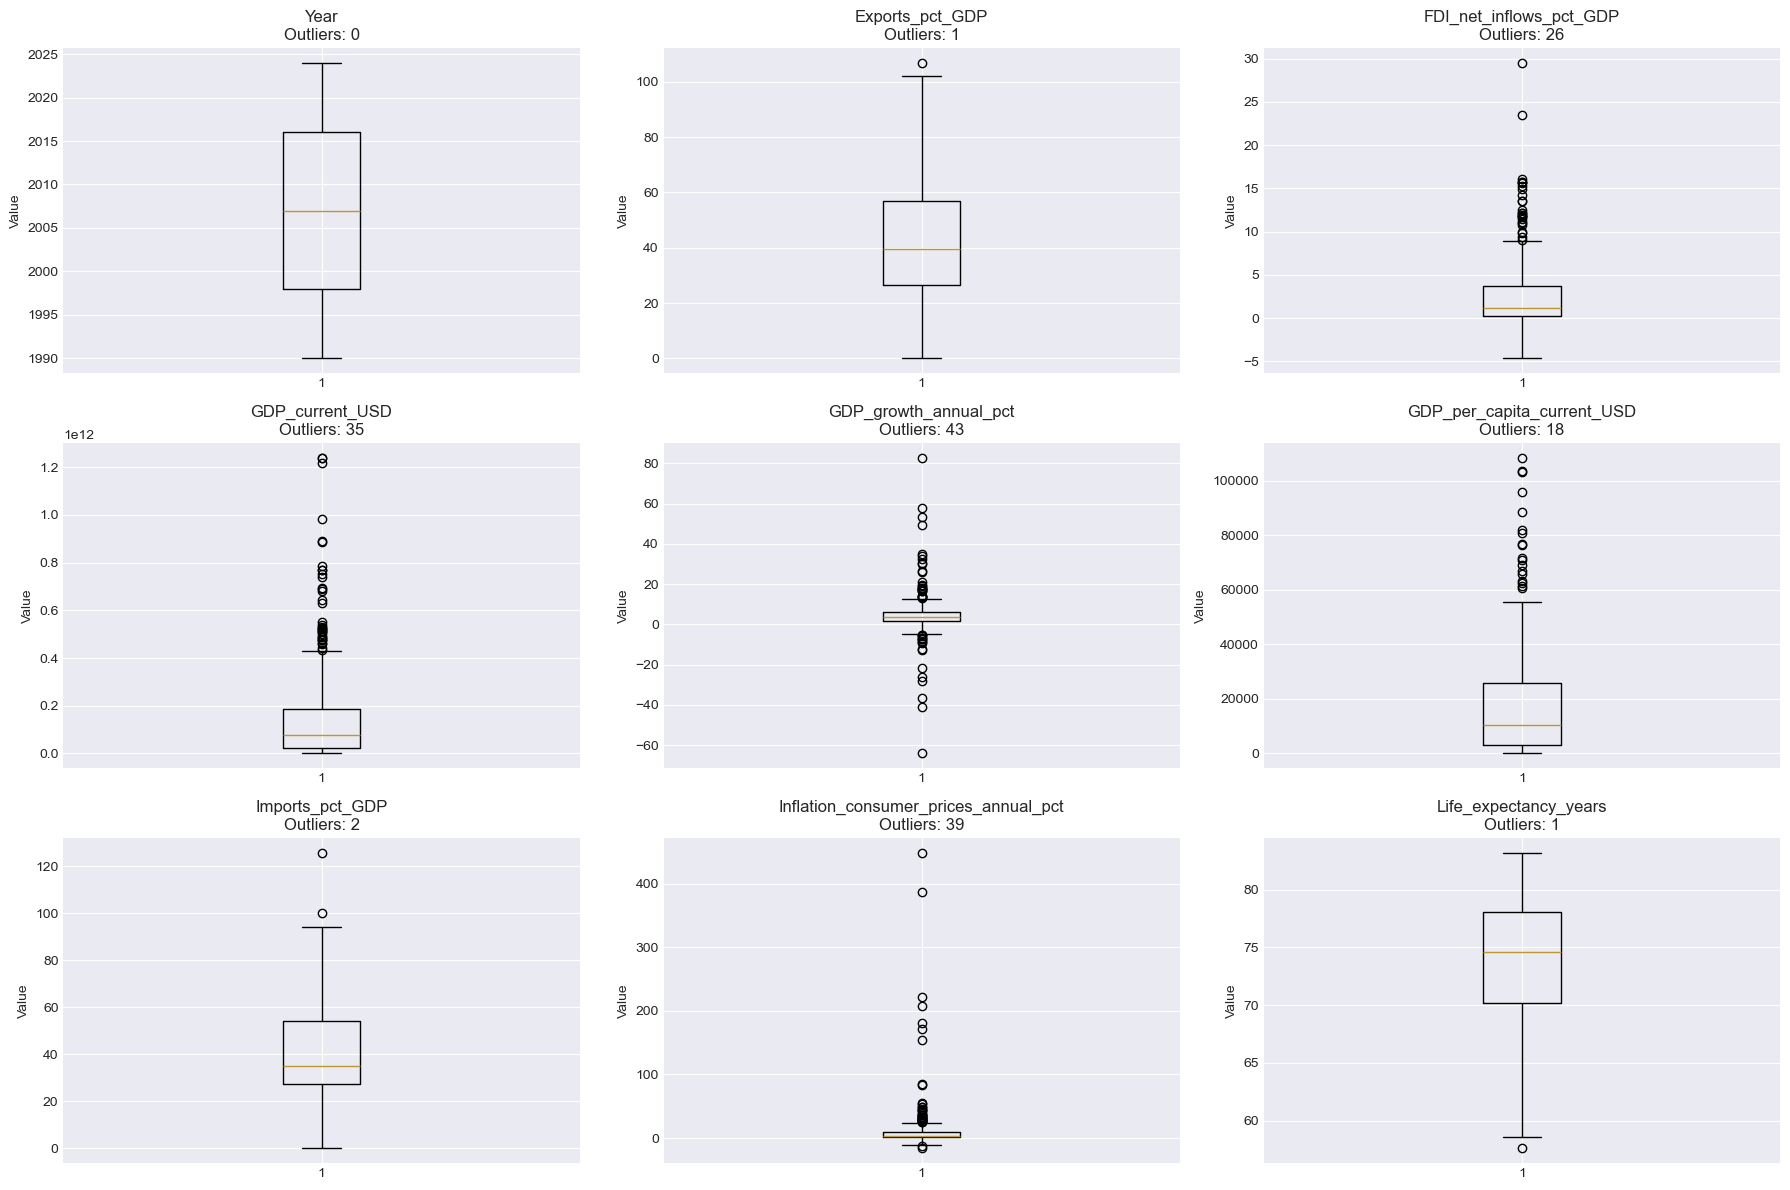


Outlier Counts by Column:
GDP_growth_annual_pct: 43 outliers
Inflation_consumer_prices_annual_pct: 39 outliers
GDP_current_USD: 35 outliers
FDI_net_inflows_pct_GDP: 26 outliers
GDP_per_capita_current_USD: 18 outliers
Imports_pct_GDP: 2 outliers
Exports_pct_GDP: 1 outliers
Life_expectancy_years: 1 outliers

EXTREME CASES INVESTIGATION

Highest GDP Growth Rates:
     Country  Year  GDP_growth_annual_pct
212   Kuwait  1992              82.809329
105     Iraq  1990              57.817828
119     Iraq  2004              53.385547
246  Lebanon  1991              49.447379
113     Iraq  1998              35.000968

Lowest GDP Growth Rates:
    Country  Year  GDP_growth_annual_pct
106    Iraq  1991             -64.047107
211  Kuwait  1991             -41.007791
118    Iraq  2003             -36.656780
445   Yemen  2015             -27.994546
210  Kuwait  1990             -26.228893


In [10]:
# Outlier detection using IQR method
def detect_outliers(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Calculate outliers count
    outlier_counts = {}
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols[:9]):  # First 9 numeric columns
        if col in df.columns:
            # IQR method
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outlier_counts[col] = len(outliers)
            
            # Box plot
            axes[idx].boxplot(df[col].dropna())
            axes[idx].set_title(f'{col}\nOutliers: {len(outliers)}')
            axes[idx].set_ylabel('Value')
            
            # Highlight outliers in scatter
            if len(outliers) > 0:
                colors = ['red' if (x < lower_bound or x > upper_bound) else 'blue' 
                         for x in df[col]]
    
    plt.tight_layout()
    plt.show()
    
    print("\nOutlier Counts by Column:")
    for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            print(f"{col}: {count} outliers")
    
    # Investigate extreme cases
    print("\n" + "="*50)
    print("EXTREME CASES INVESTIGATION")
    print("="*50)
    
    # GDP growth extremes
    extreme_growth = df.nlargest(5, 'GDP_growth_annual_pct')[['Country', 'Year', 'GDP_growth_annual_pct']]
    print("\nHighest GDP Growth Rates:")
    print(extreme_growth)
    
    extreme_negative = df.nsmallest(5, 'GDP_growth_annual_pct')[['Country', 'Year', 'GDP_growth_annual_pct']]
    print("\nLowest GDP Growth Rates:")
    print(extreme_negative)
    
    return outlier_counts

outliers = detect_outliers(df)

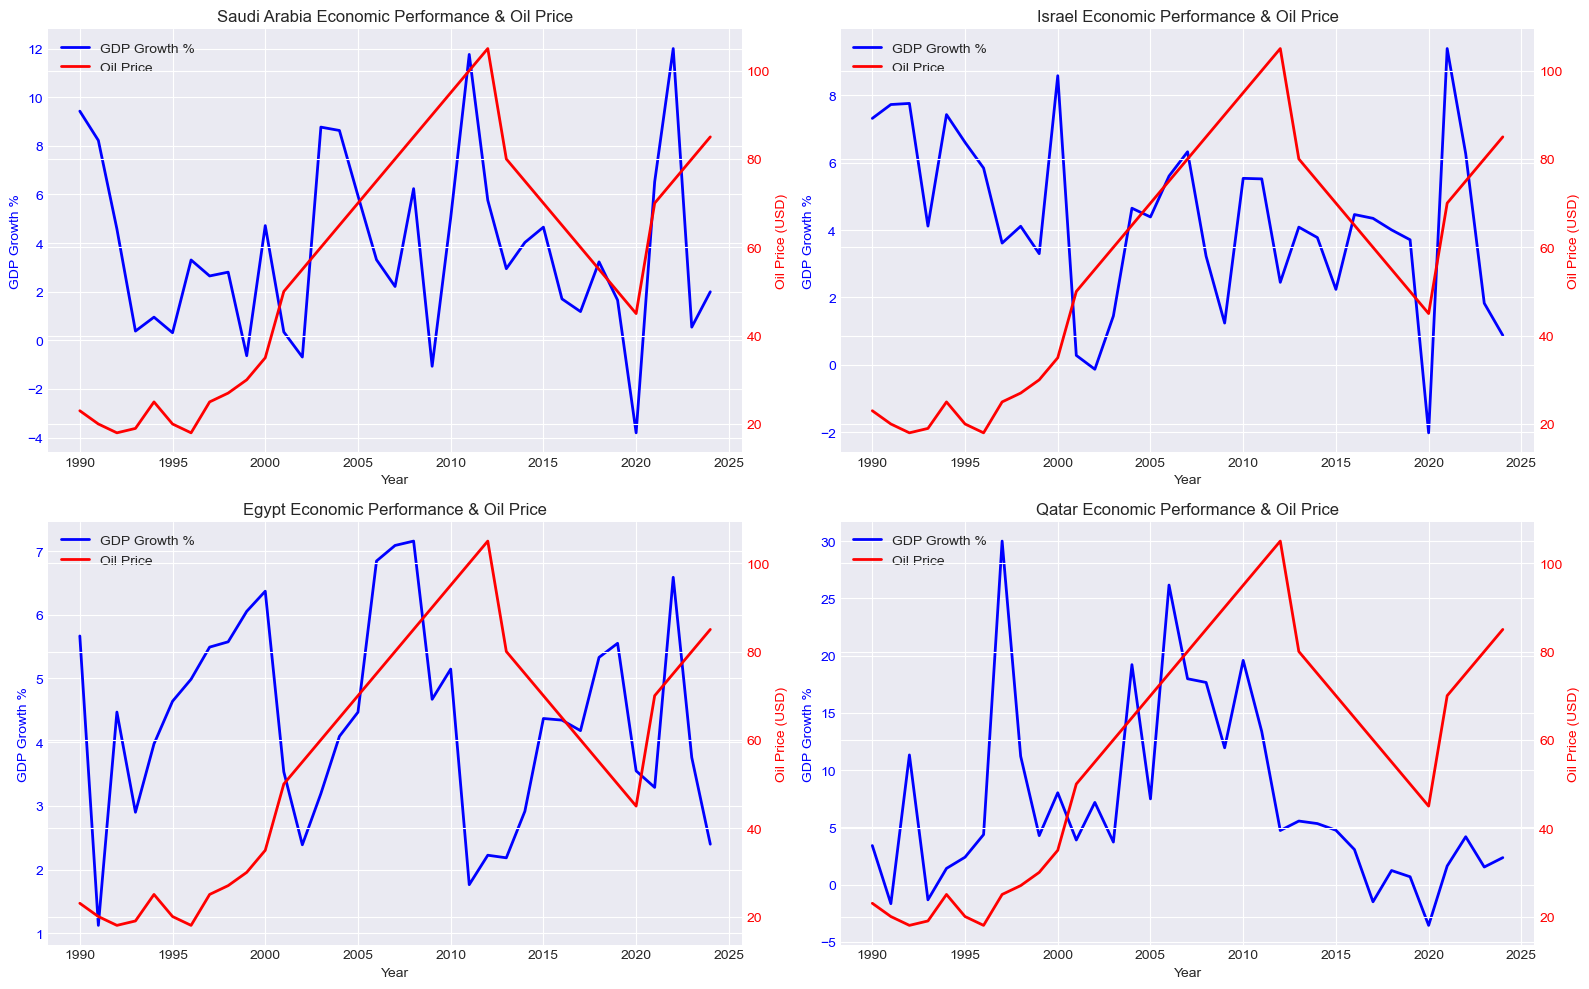

In [20]:
# Deep dive into specific countries of interest
def country_deep_dive(df, countries=['Saudi Arabia', 'Israel', 'Egypt', 'Qatar']):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, country in enumerate(countries):
        country_data = df[df['Country'] == country].copy()
        
        # Create twin axis
        ax1 = axes[idx]
        ax2 = ax1.twinx()
        
        # Plot GDP and Oil Price
        ax1.plot(country_data['Year'], country_data['GDP_growth_annual_pct'], 
                'b-', linewidth=2, label='GDP Growth %')
        ax1.set_xlabel('Year')
        ax1.set_ylabel('GDP Growth %', color='b')
        ax1.tick_params(axis='y', labelcolor='b')
        
        ax2.plot(country_data['Year'], country_data['Brent_Oil_Price_USD_per_barrel'], 
                'r-', linewidth=2, label='Oil Price')
        ax2.set_ylabel('Oil Price (USD)', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        
        # Highlight conflict periods
        if country == 'Iraq':
            ax1.axvspan(2003, 2011, alpha=0.2, color='gray', label='Iraq War')
        elif country == 'Syria':
            ax1.axvspan(2011, 2024, alpha=0.2, color='gray', label='Civil War')
        elif country == 'Yemen':
            ax1.axvspan(2015, 2024, alpha=0.2, color='gray', label='Conflict')
        elif country == 'Lebanon':
            ax1.axvspan(2019, 2024, alpha=0.2, color='gray', label='Crisis')
        
        ax1.set_title(f'{country} Economic Performance & Oil Price')
        
        # Add legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

country_deep_dive(df)

In [12]:
# Quantify oil price impact
def oil_impact_summary(df):
    # Split countries by oil dependence
    oil_exporters = ['Saudi Arabia', 'UAE', 'Kuwait', 'Qatar', 'Iraq', 'Iran', 'Oman', 'Bahrain']
    diversified = ['Israel', 'Egypt', 'Jordan', 'Lebanon', 'Yemen']
    
    df['Country_Type'] = df['Country'].apply(
        lambda x: 'Oil Exporter' if x in oil_exporters else 'Diversified'
    )
    
    # Compare performance in high vs low oil price periods
    oil_threshold = df['Brent_Oil_Price_USD_per_barrel'].median()
    
    summary = df.groupby(['Country_Type', 
                          df['Brent_Oil_Price_USD_per_barrel'] > oil_threshold]).agg({
        'GDP_growth_annual_pct': 'mean',
        'Inflation_consumer_prices_annual_pct': 'mean',
        'Unemployment_total_pct': 'mean'
    }).round(2)
    
    print("Economic Performance: High vs Low Oil Prices")
    print("="*60)
    print(summary)
    
    return summary

oil_summary = oil_impact_summary(df)

Economic Performance: High vs Low Oil Prices
                                             GDP_growth_annual_pct  \
Country_Type Brent_Oil_Price_USD_per_barrel                          
Diversified  False                                            4.53   
             True                                             3.51   
Oil Exporter False                                            4.15   
             True                                             5.44   

                                             Inflation_consumer_prices_annual_pct  \
Country_Type Brent_Oil_Price_USD_per_barrel                                         
Diversified  False                                                          10.07   
             True                                                           12.44   
Oil Exporter False                                                          16.74   
             True                                                            6.94   

                       

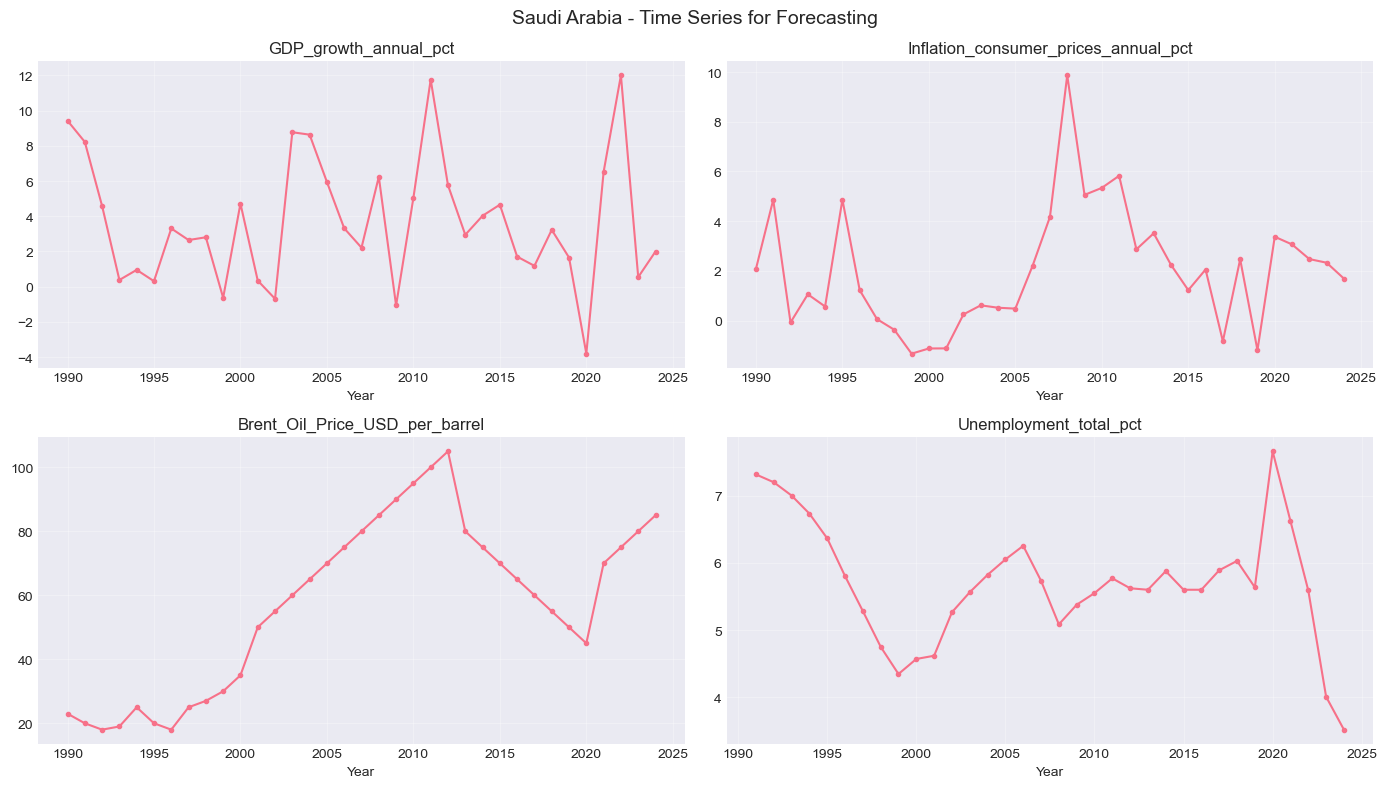

In [13]:
# Prepare data for time series forecasting
def prepare_forecasting_data(df, country='Saudi Arabia'):
    """
    Prepare country-specific data for forecasting
    """
    country_data = df[df['Country'] == country].copy()
    country_data = country_data.set_index('Year')
    country_data = country_data.sort_index()
    
    # Select key variables for forecasting
    forecast_vars = ['GDP_growth_annual_pct', 'Inflation_consumer_prices_annual_pct',
                    'Brent_Oil_Price_USD_per_barrel', 'Unemployment_total_pct']
    
    # Handle missing values
    country_data_clean = country_data[forecast_vars].interpolate(method='linear')
    
    # Plot time series
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'{country} - Time Series for Forecasting', fontsize=14)
    
    for idx, var in enumerate(forecast_vars):
        row, col = idx // 2, idx % 2
        axes[row, col].plot(country_data_clean.index, country_data_clean[var], 
                           marker='o', markersize=3)
        axes[row, col].set_title(var)
        axes[row, col].set_xlabel('Year')
        axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return country_data_clean

# Example for Saudi Arabia
saudi_forecast_data = prepare_forecasting_data(df, 'Saudi Arabia')

In [14]:
# Pseudo-code for predictive modeling

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Predict GDP growth based on oil prices and other indicators
features = ['Brent_Oil_Price_USD_per_barrel', 'Exports_pct_GDP', 
            'FDI_net_inflows_pct_GDP', 'Inflation_consumer_prices_annual_pct']
target = 'GDP_growth_annual_pct'
#drop rows with NaN values in the target variable
df_clean = df.dropna(subset=[target])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_clean[features], df_clean[target], test_size=0.2, random_state=42
)

# Model training
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Feature importance analysis
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)


In [18]:
# Complete analysis pipeline
def complete_middle_east_analysis(df):
    """
    Run complete Middle East economic analysis
    """
    print("="*60)
    print("MIDDLE EAST ECONOMIC ANALYSIS 1990-2024")
    print("="*60)
    
    # 1. Data Overview
    print("\n1. DATA OVERVIEW")
    print(f"Dataset Shape: {df.shape}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Years: {df['Year'].min()} - {df['Year'].max()}")
    
    # 2. Missing Values
    print("\n2. MISSING VALUES")
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    print(missing_pct[missing_pct > 0].round(2))
    
    # 3. Summary Statistics
    print("\n3. SUMMARY STATISTICS")
    print(df.describe().round(2))
    
    # 4. Correlation with Oil
    print("\n4. OIL PRICE CORRELATIONS")
    oil_corr = df.corr(numeric_only=True)['Brent_Oil_Price_USD_per_barrel'].sort_values(ascending=False)
    print(oil_corr.round(3))
    
    # 5. Country Rankings
    print("\n5. COUNTRY RANKINGS (2024)")
    latest = df[df['Year'] == 2024]
    print("\nLargest Economies (GDP in Billion USD):")
    print(latest.nlargest(5, 'GDP_current_USD')[['Country', 'GDP_current_USD']].assign(
        GDP_current_USD=lambda x: x['GDP_current_USD'] / 1e9).round(2))
    
    print("\nHighest GDP per Capita:")
    print(latest.nlargest(5, 'GDP_per_capita_current_USD')[['Country', 'GDP_per_capita_current_USD']].round(2))
    
    return {
        'shape': df.shape,
        'missing': missing_pct,
        'oil_corr': oil_corr,
        'latest_data': latest
    }

# Run the complete analysis
results = complete_middle_east_analysis(df)

# Create a single summary report with multiple sections
with open('MIDDLE EAST ECONOMY,OIL PRICES ANALYSIS (1990-2024) SUMMARY REPORT.csv', 'w', newline='') as f:
    f.write("MIDDLE EAST ECONOMIC ANALYSIS 1990-2024 SUMMARY REPORT\n\n")
    
    # Dataset Overview
    f.write("1. DATASET OVERVIEW\n")
    f.write(f"Rows,{results['shape'][0]}\n")
    f.write(f"Columns,{results['shape'][1]}\n")
    f.write(f"Countries,{df['Country'].nunique()}\n")
    f.write(f"Year Range,{df['Year'].min()}-{df['Year'].max()}\n\n")
    
    # Missing Values
    f.write("2. MISSING VALUES (%)\n")
    missing_data = results['missing'][results['missing'] > 0].round(2)
    for col, pct in zip(missing_data.index, missing_data.values):
        f.write(f"{col},{pct}\n")
    f.write("\n")
    
    # Oil Price Correlations
    f.write("3. OIL PRICE CORRELATIONS\n")
    for feature, corr in zip(results['oil_corr'].index, results['oil_corr'].values):
        f.write(f"{feature},{corr:.3f}\n")
    f.write("\n")
    
    # Top 5 Economies by GDP
    f.write("4. TOP 5 ECONOMIES BY GDP (2024, Billion USD)\n")
    top_gdp = results['latest_data'].nlargest(5, 'GDP_current_USD')[['Country', 'GDP_current_USD']]
    for country, gdp in zip(top_gdp['Country'], top_gdp['GDP_current_USD']):
        f.write(f"{country},{gdp/1e9:.2f}\n")
    f.write("\n")
    
    # Top 5 by GDP per Capita
    f.write("5. TOP 5 BY GDP PER CAPITA (2024, USD)\n")
    top_gdp_pc = results['latest_data'].nlargest(5, 'GDP_per_capita_current_USD')[['Country', 'GDP_per_capita_current_USD']]
    for country, gdp_pc in zip(top_gdp_pc['Country'], top_gdp_pc['GDP_per_capita_current_USD']):
        f.write(f"{country},{gdp_pc:.2f}\n")

print("\nSummary report saved as 'MIDDLE EAST ECONOMY,OIL PRICES ANALYSIS (1990-2024) SUMMARY REPORT.csv'")

MIDDLE EAST ECONOMIC ANALYSIS 1990-2024

1. DATA OVERVIEW
Dataset Shape: (455, 14)
Countries: 13
Years: 1990 - 2024

2. MISSING VALUES
Inflation_consumer_prices_annual_pct    13.19
Exports_pct_GDP                          5.71
Imports_pct_GDP                          5.71
Unemployment_total_pct                   3.08
Life_expectancy_years                    2.86
FDI_net_inflows_pct_GDP                  1.98
GDP_growth_annual_pct                    1.76
GDP_current_USD                          1.54
GDP_per_capita_current_USD               1.54
dtype: float64

3. SUMMARY STATISTICS
          Year  Exports_pct_GDP  FDI_net_inflows_pct_GDP  GDP_current_USD  \
count   455.00           429.00                   446.00     4.480000e+02   
mean   2007.00            43.28                     2.42     1.493333e+11   
std      10.11            22.15                     3.76     1.935098e+11   
min    1990.00             0.01                    -4.65     4.077963e+08   
25%    1998.00            26